In [1]:
import huggingface_hub as hf
import pandas as pd
import pathlib
import re
import itertools
import collections
from tqdm import tqdm
import plotly.express as px

In [2]:
parquet_path = hf.hf_hub_download(
    "stanfordnlp/imdb", "plain_text/train-00000-of-00001.parquet", 
    repo_type="dataset")
parquet_path

'/Users/shmuma/.cache/huggingface/hub/datasets--stanfordnlp--imdb/snapshots/e6281661ce1c48d982bc483cf8a173c1bbeb5d31/plain_text/train-00000-of-00001.parquet'

In [3]:
df = pd.read_parquet(parquet_path)
df

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0
...,...,...
24995,A hit at the time but now better categorised a...,1
24996,I love this movie like no other. Another time ...,1
24997,This film and it's sequel Barry Mckenzie holds...,1
24998,'The Adventures Of Barry McKenzie' started lif...,1


In [4]:
for path in ("train-00000-of-00001.parquet", "test-00000-of-00001.parquet", 
             "unsupervised-00000-of-00001.parquet"):
    p = hf.hf_hub_download(
        "stanfordnlp/imdb", "plain_text/" + path, 
        repo_type="dataset")
    p = pathlib.Path(p)
    print(f"{p.name}: {p.stat().st_size}")

train-00000-of-00001.parquet: 20979968
test-00000-of-00001.parquet: 20470363
unsupervised-00000-of-00001.parquet: 41996509


In [5]:
df.iloc[2].to_dict()

{'text': "If only to avoid making this type of film in the future. This film is interesting as an experiment but tells no cogent story.<br /><br />One might feel virtuous for sitting thru it because it touches on so many IMPORTANT issues but it does so without any discernable motive. The viewer comes away with no new perspectives (unless one comes up with one while one's mind wanders, as it will invariably do during this pointless film).<br /><br />One might better spend one's time staring out a window at a tree growing.<br /><br />",
 'label': 0}

In [6]:
df['text_len'] = df.text.map(len)
print(df.describe())

             label     text_len
count  25000.00000  25000.00000
mean       0.50000   1325.06964
std        0.50001   1003.13367
min        0.00000     52.00000
25%        0.00000    702.00000
50%        0.50000    979.00000
75%        1.00000   1614.00000
max        1.00000  13704.00000


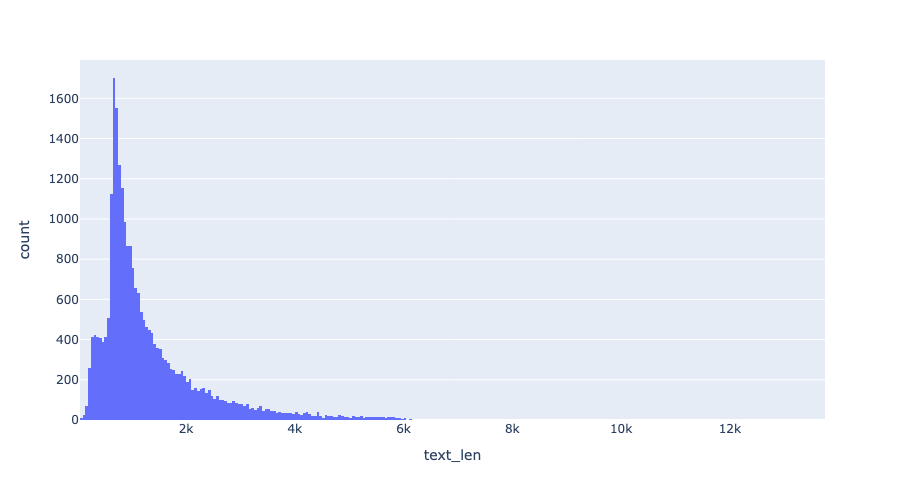

In [7]:
px.histogram(df, 'text_len', width=700, height=500)

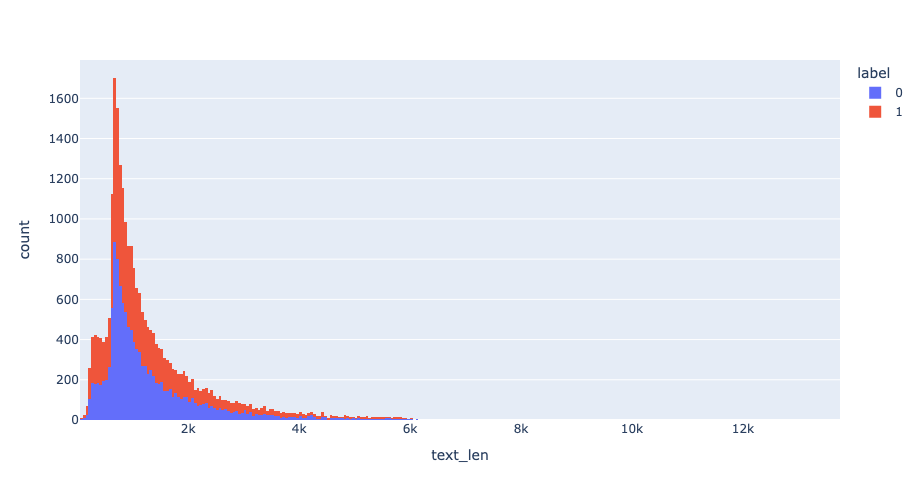

In [8]:
px.histogram(df, 'text_len', color='label', width=700, height=500, barmode="stack")

# Check html tags

In [9]:
count_tags = collections.Counter()
tag_re = re.compile(r"<[\w\s/]+>")
for s in df.text:
    found = tag_re.findall(s)
    count_tags.update(found)
count_tags.most_common()

[('<br />', 101870),
 ('<i>', 7),
 ('</i>', 7),
 ('<hr>', 1),
 ('<grin>', 1),
 ('<SPOILER>', 1),
 ('</SPOILER>', 1),
 ('<em>', 1),
 ('</em>', 1),
 ('<sigh>', 1)]

# Tokenization of reviews

In [10]:
from tokenizers import Tokenizer, Regex
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.normalizers import NFD, StripAccents, Sequence, Replace, Lowercase

In [11]:
model = BPE(unk_token="[UNK]")
trainer = BpeTrainer(special_tokens=["[UNK]"], show_progress=False)
tokenizer = Tokenizer(model)
tokenizer.pre_tokenizer = Whitespace()

In [12]:
CAT_TEXTS = ["This is a cat", "The cat is unbelievable fat"]
tokenizer.train_from_iterator(CAT_TEXTS, trainer=trainer)

In [13]:
print(tokenizer.get_vocab())

{'u': 13, 'at': 15, 'T': 1, 'This': 29, 'f': 6, 'unbelievable': 32, 'cat': 18, 'n': 10, 'v': 14, 'is': 16, 'ev': 21, 'ab': 19, 'h': 7, 'le': 24, 'fat': 22, 'nbe': 26, 'Th': 17, 'The': 28, 'c': 4, 'unbe': 27, 's': 11, 'e': 5, 'l': 9, 'iev': 23, 'i': 8, '[UNK]': 0, 'be': 20, 'a': 2, 't': 12, 'liev': 25, 'b': 3, 'lievable': 31, 'able': 30}


In [14]:
enc = tokenizer.encode("Very fat cat")
print(enc.tokens)
print(enc.ids)

['[UNK]', 'e', '[UNK]', '[UNK]', 'fat', 'cat']
[0, 5, 0, 0, 22, 18]


In [15]:
model = BPE(unk_token="[UNK]")
trainer = BpeTrainer(special_tokens=["[UNK]"], show_progress=False)
tokenizer = Tokenizer(model)
tokenizer.normalizer = Sequence([
    NFD(), StripAccents(), Replace(Regex(r"<[\w\s/]+>"), " "), Lowercase()
])
tokenizer.pre_tokenizer = Whitespace()

In [16]:
text = df.iloc[2].to_dict()['text']
tokenizer.train_from_iterator([text], trainer=trainer)
tokenizer.get_vocab_size()

212

In [17]:
out = tokenizer.encode(text)
print(len(text), len(out.ids))
print(out.tokens)

528 100
['if', 'only', 'to', 'avoid', 'making', 'this', 'type', 'of', 'film', 'in', 'the', 'future', '.', 'this', 'film', 'is', 'interesting', 'as', 'an', 'experiment', 'but', 'tells', 'no', 'cogent', 'story', '.', 'one', 'might', 'feel', 'virtuous', 'for', 'sitting', 'thru', 'it', 'because', 'it', 'touches', 'on', 'so', 'many', 'important', 'issues', 'but', 'it', 'does', 'so', 'without', 'any', 'discernable', 'motive', '.', 'the', 'viewer', 'comes', 'away', 'with', 'no', 'new', 'perspectives', '(', 'unless', 'one', 'comes', 'up', 'with', 'one', 'while', 'one', "'", 's', 'mind', 'wanders', ',', 'as', 'it', 'will', 'invariably', 'do', 'during', 'this', 'pointless', 'film', ').', 'one', 'might', 'better', 'spend', 'one', "'", 's', 'time', 'staring', 'out', 'a', 'window', 'at', 'a', 'tree', 'growing', '.']


In [18]:
out = tokenizer.encode("invariability")
out.tokens

['invar', 'iab', 'il', 'it', 'y']

In [40]:
import data

texts, _ = data.load_dataset()
unlabeled_texts = data.load_dataset_unlabelled()
texts.extend(unlabeled_texts)
len(texts)

100000

In [41]:
%time tokenizer = data.train_tokenizer(texts)
list(tokenizer.get_vocab().items())[:10]

CPU times: user 21 s, sys: 7.32 s, total: 28.4 s
Wall time: 2.89 s


[('dooley', 28328),
 ('hammers', 27919),
 ('starlets', 27222),
 ('hay', 3551),
 ('trot', 16504),
 ('nasa', 14767),
 ('enlist', 17079),
 ('approached', 10786),
 ('exploitive', 20107),
 ('unforgettable', 6173)]

In [43]:
list(sorted(tokenizer.get_vocab().items()))[:15]

[('\x08', 5),
 ('\x10', 6),
 ('\x18', 7),
 ('!', 8),
 ('!!', 598),
 ('!!!', 1715),
 ('!!!!', 2253),
 ('!!!!!', 6609),
 ('!!!!!!', 13211),
 ('!!!!!!!', 16500),
 ('!!!!!!!!', 6262),
 ('!!!!!!!!!', 22856),
 ('!!!!!!!!!!', 28757),
 ('!!!!!!!!!!!!!!!!', 16437),
 ('!!!"', 17523)]

[('practical', 9572),
 ('30th', 26628),
 ('granger', 13391),
 ('fewer', 14936),
 ('pj', 28477),
 ('notions', 13607),
 ('courtroom', 9576),
 ('pimp', 9007),
 ('kersey', 15022),
 ('mascot', 21848)]

In [23]:
tokenizer.get_vocab()["exactly"]

1788

In [26]:
tokenizer.encode("EXACTLY").ids

[1788]

In [54]:
tokenizer.get_vocab_size()

30000

In [27]:
tokenizer.save("tokenizer.json")

# Language detection

In [25]:
from transformers import pipeline

In [26]:
lang_detection = pipeline("text-classification", "papluca/xlm-roberta-base-language-detection")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [27]:
lang_detection(text, top_k=1)

[{'label': 'en', 'score': 0.9802564382553101}]

In [29]:
lang_scores = []
trimmed_reviews = df.text.map(lambda s: s[:512])
for batch in tqdm(itertools.batched(trimmed_reviews, 128)):
    scores = lang_detection(list(batch))
    lang_scores.extend(scores)

196it [05:15,  1.61s/it]


In [30]:
df['lang'] = list(map(lambda d: d['label'], lang_scores))

In [31]:
df.lang.value_counts()

lang
en    24997
hi        2
pt        1
Name: count, dtype: int64